In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("youtube_shorts_tiktok_trends_2025.csv")

df.head()

,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,...,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,...,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,...,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,...,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,...,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,...,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142


In [5]:
print(df.shape)

df.info()

(48079, 58)
<class 'pandas.DataFrame'>
RangeIndex: 48079 entries, 0 to 48078
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 48079 non-null  str    
 1   country                  48079 non-null  str    
 2   region                   48079 non-null  str    
 3   language                 48079 non-null  str    
 4   category                 48079 non-null  str    
 5   hashtag                  48079 non-null  str    
 6   title_keywords           48079 non-null  str    
 7   author_handle            48079 non-null  str    
 8   sound_type               48079 non-null  str    
 9   music_track              48079 non-null  str    
 10  week_of_year             48079 non-null  int64  
 11  duration_sec             48079 non-null  int64  
 12  views                    48079 non-null  int64  
 13  likes                    48079 non-null  int64  
 14  comments             

In [6]:
df.isnull().sum()

platform                   0
country                    0
region                     0
language                   0
category                   0
hashtag                    0
title_keywords             0
author_handle              0
sound_type                 0
music_track                0
week_of_year               0
duration_sec               0
views                      0
likes                      0
comments                   0
shares                     0
saves                      0
engagement_rate            0
trend_label                0
source_hint                0
notes                      0
device_type                0
upload_hour                0
genre                      0
trend_duration_days        0
trend_type                 0
engagement_velocity        0
dislikes                   0
comment_ratio              0
share_rate                 0
save_rate                  0
like_dislike_ratio         0
publish_dayofweek          0
publish_period             0
event_season  

In [25]:
required_for_label = [
    "completion_rate",
    "engagement_velocity",
    "avg_watch_time_sec",
    "duration_sec"
]

for col in required_for_label:
    if col not in df.columns:
        raise ValueError(f"Required column missing: {col}")

In [26]:
df["completion_rate"] = df["completion_rate"].fillna(
    df["completion_rate"].median()
)

df["engagement_velocity"] = df["engagement_velocity"].fillna(
    df["engagement_velocity"].median()
)

df["avg_watch_time_sec"] = df["avg_watch_time_sec"].fillna(
    df["avg_watch_time_sec"].median()
)

df["duration_sec"] = df["duration_sec"].replace(
    0,
    np.nan
)

df["duration_sec"] = df["duration_sec"].fillna(
    df["duration_sec"].median()
)

In [27]:
df["watch_ratio"] = (
    df["avg_watch_time_sec"]
    /
    df["duration_sec"]
)

df["watch_ratio"] = df["watch_ratio"].replace(
    [np.inf, -np.inf],
    np.nan
)

df["watch_ratio"] = df["watch_ratio"].fillna(
    df["watch_ratio"].median()
)

In [28]:
df["completion_rank"] = (
    df["completion_rate"]
    .rank(pct=True)
)

df["engagement_rank"] = (
    df["engagement_velocity"]
    .rank(pct=True)
)

df["watch_ratio_rank"] = (
    df["watch_ratio"]
    .rank(pct=True)
)

In [29]:
df["viral_score"] = (
      0.45 * df["completion_rank"]
    + 0.40 * df["engagement_rank"]
    + 0.15 * df["watch_ratio_rank"]
)

In [30]:
cutoff = df["viral_score"].quantile(0.80)

df["trend_label"] = (
    df["viral_score"] >= cutoff
).astype(int)

print(df["trend_label"].value_counts())

trend_label
0    38463
1     9616
Name: count, dtype: int64


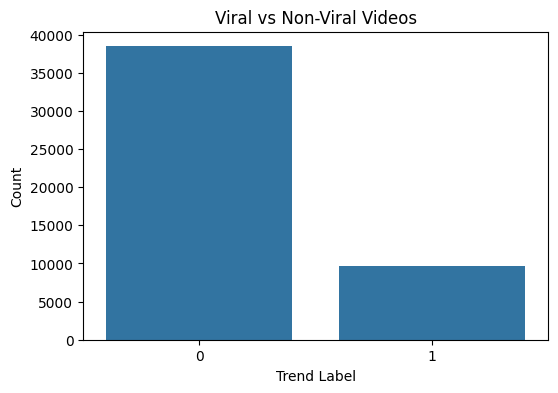

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["trend_label"])

plt.title("Viral vs Non-Viral Videos")
plt.xlabel("Trend Label")
plt.ylabel("Count")

plt.show()

In [31]:
logit_features = [
    "platform",
    "category",
    "duration_sec",
    "completion_rate",
    "engagement_velocity",
    "upload_hour",
    "has_emoji"
]

logit_df = df[
    logit_features + ["trend_label"]
].copy()

In [32]:
logit_df = logit_df.dropna()

In [33]:
X_logit = logit_df[logit_features]

y_logit = logit_df["trend_label"]

In [34]:
categorical_features = [
    "platform",
    "category"
]

In [35]:
numerical_features = [
    "duration_sec",
    "completion_rate",
    "engagement_velocity",
    "upload_hour",
    "has_emoji"
]

In [36]:
preprocessor_log = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            SimpleImputer(
                strategy="median"
            ),
            numerical_features
        )
    ]
)

In [37]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_logit,
    y_logit,
    test_size=0.4,
    random_state=98
)

In [38]:
log_model = Pipeline(
    steps=[
        (
            "preprocess",
            preprocessor_log
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

log_model.fit(
    X_train_log,
    y_train_log
)

C:\Users\ANSH SHARMA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [39]:
y_pred_log = log_model.predict(
    X_test_log
)

In [40]:
accuracy = accuracy_score(
    y_test_log,
    y_pred_log
)

print("Accuracy:", accuracy)

Accuracy: 0.8907549916805324


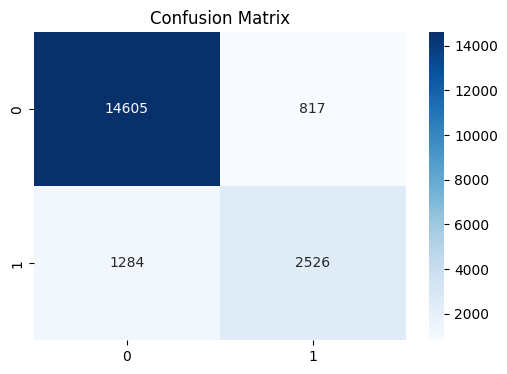

In [41]:
cm = confusion_matrix(
    y_test_log,
    y_pred_log
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [42]:
print(
    classification_report(
        y_test_log,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.92      0.95      0.93     15422
           1       0.76      0.66      0.71      3810

    accuracy                           0.89     19232
   macro avg       0.84      0.81      0.82     19232
weighted avg       0.89      0.89      0.89     19232



In [43]:
linear_features = [
    "duration_sec",
    "avg_watch_time_sec",
    "platform",
    "category",
    "event_season",
    "traffic_source"
]

linear_features = [
    col for col in linear_features
    if col in df.columns
]

linear_df = df[
    linear_features + ["completion_rate"]
].copy()

linear_df.head()

,duration_sec,avg_watch_time_sec,platform,category,event_season,traffic_source,completion_rate
0,40,25.8,TikTok,Gaming,Regular,External,0.645
1,18,10.4,TikTok,Food,Regular,Search,0.578
2,22,11.7,TikTok,Art,Regular,External,0.532
3,36,23.7,TikTok,News,SummerBreak,Search,0.658
4,35,24.6,TikTok,Beauty,Regular,ForYou,0.703


In [44]:
linear_df = linear_df.dropna()

print(linear_df.shape)

(48079, 7)


In [45]:
X_lin = linear_df[linear_features]

y_lin = linear_df["completion_rate"]

In [46]:
cat_features_lin = [
    "platform",
    "category",
    "event_season",
    "traffic_source"
]

In [47]:
num_features_lin = [
    "duration_sec",
    "avg_watch_time_sec"
]

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

preprocessor_lin = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features_lin
        ),
        (
            "num",
            SimpleImputer(strategy="median"),
            num_features_lin
        )
    ]
)

In [49]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin,
    y_lin,
    test_size=0.4,
    random_state=98
)

In [50]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocess", preprocessor_lin),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train_lin,
    y_train_lin
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [51]:
y_pred_lin = linear_model.predict(
    X_test_lin
)

In [52]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test_lin,
    y_pred_lin
)

print("MAE:", mae)

MAE: 0.034963892553197866


In [53]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test_lin,
    y_pred_lin
)

print("MSE:", mse)

MSE: 0.0021905882771117383


In [54]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.046803720761406764


In [55]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test_lin,
    y_pred_lin
)

print("R² Score:", r2)

R² Score: 0.8272905686327878


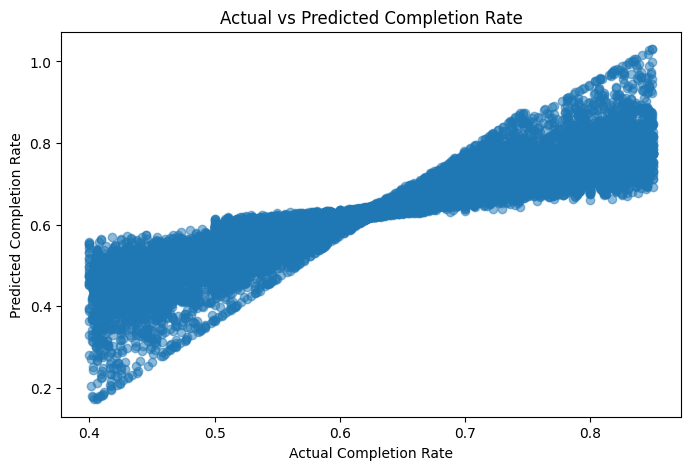

In [56]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_lin,
    y_pred_lin,
    alpha=0.5
)

plt.xlabel("Actual Completion Rate")
plt.ylabel("Predicted Completion Rate")
plt.title("Actual vs Predicted Completion Rate")

plt.show()

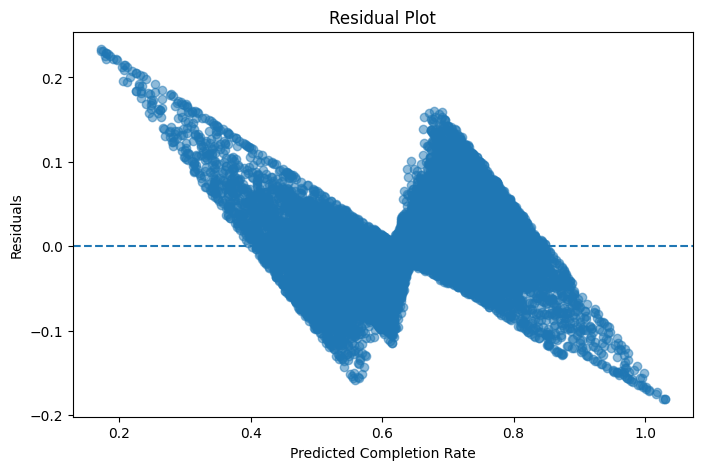

In [61]:
residuals = y_test_lin - y_pred_lin

plt.figure(figsize=(8,5))
plt.scatter(y_pred_lin, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Completion Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

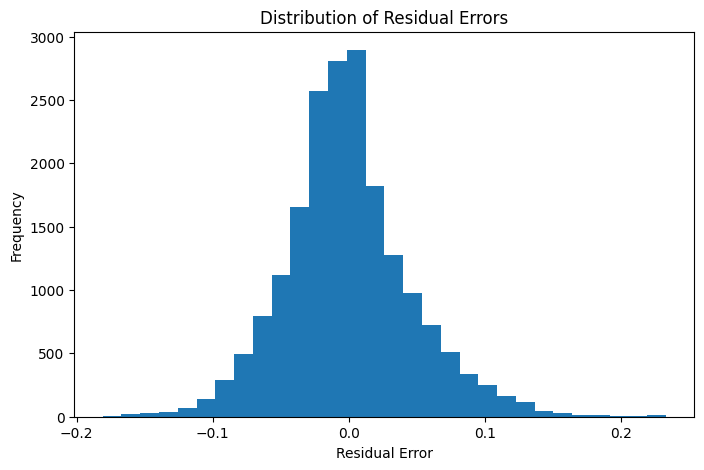

In [62]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Distribution of Residual Errors")

plt.show()

In [58]:
print("=== MODEL RESULTS ===")

print(f"Logistic Regression Accuracy: {accuracy:.4f}")

print(f"Linear Regression R2 Score: {r2:.4f}")

print(f"Linear Regression RMSE: {rmse:.4f}")

print("\nConclusion:")
print("The Logistic Regression model successfully predicts viral trends.")
print("The Linear Regression model accurately predicts completion rate.")
print("These models can help Nike optimize future influencer campaigns.")

=== MODEL RESULTS ===
Logistic Regression Accuracy: 0.8908
Linear Regression R2 Score: 0.8273
Linear Regression RMSE: 0.0468

Conclusion:
The Logistic Regression model successfully predicts viral trends.
The Linear Regression model accurately predicts completion rate.
These models can help Nike optimize future influencer campaigns.
